In this walk-through, we will focus on a few key concepts:

1. **String Indexer:** We will use the StringIndexer method to assign a numerical index to the categorical columns in the dataset. This converts categorical values into numerical values, which are necessary for machine learning models.

2. **OneHot Encoding:** We will apply OneHot encoding to the categorical columns. This technique transforms categorical variables into a format that can be easily understood by machine learning models, where each category is represented by a binary vector.

3. **String Indexer for Output Variable:** Similar to categorical columns, we will also apply the StringIndexer to the output variable (also known as the "label" column) to convert it into a numerical form that the machine learning model can process.

4. **VectorAssembler:** We will use the VectorAssembler to combine both categorical and numeric columns into a single vector column. The VectorAssembler is a transformer that takes multiple input columns and merges them into one, which is a requirement for many machine learning algorithms.

By applying these methods, we can properly prepare the data for machine learning models and ensure it is in the appropriate format.

##**Step 1**: Install Spark

###**Step 2**: Setting up Spark

Before you can connect to a Spark cluster, Spark needs to be installed. The code below is boilerplate code that can be used to set-up Spark. Please note that this code will be leveraged in all the notebooks since each nodebook is a separate entity.

### **Step 3**. Import the lib




In [3]:
# Colab-friendly setup for PySpark
!apt-get install -y openjdk-11-jdk-headless -qq > /dev/null
!pip install -q "pyspark[connect]==3.5.1" "dataproc-spark-connect==0.8.3"

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").appName("RDDPractice").getOrCreate()
sc = spark.sparkContext

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##**Step 2**: Insert SQLContext wrapper around the Spark Context

In [5]:
from pyspark.sql import SQLContext
url = "https://raw.githubusercontent.com/guru99-edu/R-Programming/master/adult_data.csv"
from pyspark import SparkFiles
sc.addFile(url)
sqlContext = SQLContext(sc)

/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:113: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


##**Step 3**: Read the contents from the 'adults.csv' file

In [6]:
df = sqlContext.read.csv(SparkFiles.get("adult_data.csv"), header=True, inferSchema= True)

##**Step 4**: Examine the schema of the underlying dataset

In [7]:
df.printSchema()

root
 |-- x: integer (nullable = true)
 |-- age: integer (nullable = true)
 |-- workclass: string (nullable = true)
 |-- fnlwgt: integer (nullable = true)
 |-- education: string (nullable = true)
 |-- educational-num: integer (nullable = true)
 |-- marital-status: string (nullable = true)
 |-- occupation: string (nullable = true)
 |-- relationship: string (nullable = true)
 |-- race: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- capital-gain: integer (nullable = true)
 |-- capital-loss: integer (nullable = true)
 |-- hours-per-week: integer (nullable = true)
 |-- native-country: string (nullable = true)
 |-- income: string (nullable = true)



In [8]:
df.show()

+---+---+----------------+------+------------+---------------+------------------+-----------------+-------------+------------------+------+------------+------------+--------------+--------------+------+
|  x|age|       workclass|fnlwgt|   education|educational-num|    marital-status|       occupation| relationship|              race|gender|capital-gain|capital-loss|hours-per-week|native-country|income|
+---+---+----------------+------+------------+---------------+------------------+-----------------+-------------+------------------+------+------------+------------+--------------+--------------+------+
|  1| 25|         Private|226802|        11th|              7|     Never-married|Machine-op-inspct|    Own-child|             Black|  Male|           0|           0|            40| United-States| <=50K|
|  2| 38|         Private| 89814|     HS-grad|              9|Married-civ-spouse|  Farming-fishing|      Husband|             White|  Male|           0|           0|            50| United-

##**Step 5**: Function that converts the data types of the DataFrame columns

In [9]:
# Write a custom function to convert the data type of DataFrame columns
def convertColumn(df, names, newType):
  for name in names:
     df = df.withColumn(name, df[name].cast(newType))
  return df

In [10]:
# Assign all column names to `columns`
columns = ['age', 'fnlwgt','capital-gain', 'educational-num', 'capital-loss', 'hours-per-week']

##**Step 6**: Convert the data types of the above mentioned columns into a float type

In [11]:
from pyspark.sql.types import *
# Conver the `df` columns to `FloatType()`
df = convertColumn(df, columns, FloatType())

##**Step 7**: Confirm that the data type has been converted into float

In [12]:
df.dtypes

[('x', 'int'),
 ('age', 'float'),
 ('workclass', 'string'),
 ('fnlwgt', 'float'),
 ('education', 'string'),
 ('educational-num', 'float'),
 ('marital-status', 'string'),
 ('occupation', 'string'),
 ('relationship', 'string'),
 ('race', 'string'),
 ('gender', 'string'),
 ('capital-gain', 'float'),
 ('capital-loss', 'float'),
 ('hours-per-week', 'float'),
 ('native-country', 'string'),
 ('income', 'string')]

##**Step 8**: Drop rows that have a '?' in them



In [13]:
import numpy as np
df = df.replace("?", "np.Nan")

# Remove missing value
df = df.filter("workclass != 'np.Nan'").filter("occupation != 'np.Nan'").filter("`native-country` != 'np.Nan'")
df.show()

+---+----+----------------+--------+------------+---------------+------------------+-----------------+-------------+-----+------+------------+------------+--------------+--------------+------+
|  x| age|       workclass|  fnlwgt|   education|educational-num|    marital-status|       occupation| relationship| race|gender|capital-gain|capital-loss|hours-per-week|native-country|income|
+---+----+----------------+--------+------------+---------------+------------------+-----------------+-------------+-----+------+------------+------------+--------------+--------------+------+
|  1|25.0|         Private|226802.0|        11th|            7.0|     Never-married|Machine-op-inspct|    Own-child|Black|  Male|         0.0|         0.0|          40.0| United-States| <=50K|
|  2|38.0|         Private| 89814.0|     HS-grad|            9.0|Married-civ-spouse|  Farming-fishing|      Husband|White|  Male|         0.0|         0.0|          50.0| United-States| <=50K|
|  3|28.0|       Local-gov|336951.0

##**Step 9:** Use "StringIndexer" and "OneHotEncoding" to convert categorical features into numeric values

In [14]:
from pyspark.ml.feature import StringIndexer
from pyspark.ml.feature import OneHotEncoder
from pyspark.ml.feature import VectorAssembler

#Store all the categorical columns
categorical_Cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']
pipeline_stages = []

#Iterate throughthe categorical columns
for categoricalCol in categorical_Cols :
    stringIndexer = StringIndexer(inputCol = categoricalCol, outputCol = categoricalCol + '_Index')
    encoder = OneHotEncoder(inputCols=[stringIndexer.getOutputCol()], outputCols=[categoricalCol + "_conv"])
    pipeline_stages += [stringIndexer, encoder]

label_stringIdx = StringIndexer(inputCol = 'income', outputCol = 'label')
#Add another stage to the ML pipeline
pipeline_stages += [label_stringIdx]

#Store all the numeric columns
numericCols = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']
assembler_Inputs = [c + "_conv" for c in categorical_Cols] + numericCols
assembler = VectorAssembler(inputCols=assembler_Inputs, outputCol="features")
pipeline_stages += [assembler]

##**Step 10**: We use the ML Pipeline to chain multiple Transformers and Estimators together to screate the machine learning workflow.

In [15]:
from pyspark.ml import Pipeline

ml_pipe = Pipeline(stages = pipeline_stages)
# Fit and transform the data
pipe_data = ml_pipe.fit(df).transform(df)
selectedCols = ['label', 'features'] + df.columns
df = pipe_data.select(selectedCols)
df.show()

+-----+--------------------+---+----+----------------+--------+------------+---------------+------------------+-----------------+-------------+-----+------+------------+------------+--------------+--------------+------+
|label|            features|  x| age|       workclass|  fnlwgt|   education|educational-num|    marital-status|       occupation| relationship| race|gender|capital-gain|capital-loss|hours-per-week|native-country|income|
+-----+--------------------+---+----+----------------+--------+------------+---------------+------------------+-----------------+-------------+-----+------+------------+------------+--------------+--------------+------+
|  0.0|(95,[0,11,22,33,4...|  1|25.0|         Private|226802.0|        11th|            7.0|     Never-married|Machine-op-inspct|    Own-child|Black|  Male|         0.0|         0.0|          40.0| United-States| <=50K|
|  0.0|(95,[0,6,21,36,40...|  2|38.0|         Private| 89814.0|     HS-grad|            9.0|Married-civ-spouse|  Farming

##**Step 11:** Split the data set into Train and Test data sets respectively

In [16]:
train, test = df.randomSplit([0.7, 0.3], seed = 12345)
print("Training Dataset Count: " + str(train.count()))
print("Test Dataset Count: " + str(test.count()))

Training Dataset Count: 31545
Test Dataset Count: 13677


##**Step 12**: Create a Logistic Regression Model

In [17]:
# Import `LogisticRegression`
from pyspark.ml.classification import LogisticRegression

# Initialize `lr`
lr = LogisticRegression(labelCol="label",
                        featuresCol="features",
                        maxIter=10,
                        regParam=0.3)

# Fit the data to the model
linearModel = lr.fit(train)

##**Step 13**: Make predictions on test data using the transform() method.


In [18]:
predictions = linearModel.transform(test)

##**Step 14**: Examine the elements in predictions object

In [19]:
predictions.printSchema()

root
 |-- label: double (nullable = false)
 |-- features: vector (nullable = true)
 |-- x: integer (nullable = true)
 |-- age: float (nullable = true)
 |-- workclass: string (nullable = true)
 |-- fnlwgt: float (nullable = true)
 |-- education: string (nullable = true)
 |-- educational-num: float (nullable = true)
 |-- marital-status: string (nullable = true)
 |-- occupation: string (nullable = true)
 |-- relationship: string (nullable = true)
 |-- race: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- capital-gain: float (nullable = true)
 |-- capital-loss: float (nullable = true)
 |-- hours-per-week: float (nullable = true)
 |-- native-country: string (nullable = true)
 |-- income: string (nullable = true)
 |-- rawPrediction: vector (nullable = true)
 |-- probability: vector (nullable = true)
 |-- prediction: double (nullable = false)



##**Step 15**: Investigate the predictions

In [20]:
predictions.select( 'label', 'rawPrediction', 'prediction', 'probability').show(50)

+-----+--------------------+----------+--------------------+
|label|       rawPrediction|prediction|         probability|
+-----+--------------------+----------+--------------------+
|  0.0|[0.86870439450838...|       0.0|[0.70447603795007...|
|  0.0|[0.87205298562233...|       0.0|[0.70517270196544...|
|  0.0|[0.50974157579245...|       0.0|[0.62474589184790...|
|  0.0|[0.73040941057940...|       0.0|[0.67489510848530...|
|  0.0|[0.77311698834401...|       0.0|[0.68419477488161...|
|  0.0|[0.64718007958056...|       0.0|[0.65637471899290...|
|  0.0|[0.69283267526089...|       0.0|[0.66659677293712...|
|  0.0|[0.43145902500777...|       0.0|[0.60622201625957...|
|  0.0|[0.22483821111194...|       0.0|[0.55597395058242...|
|  0.0|[1.08790862076715...|       0.0|[0.74798769672425...|
|  0.0|[1.14855316103718...|       0.0|[0.75924654668656...|
|  0.0|[1.04917533488512...|       0.0|[0.74061650940406...|
|  0.0|[1.02690321384842...|       0.0|[0.73631507891832...|
|  0.0|[1.02756591265401

##**Step 16**: Evaluate the predictions

**Evaluating the Model** - Since the Logistic Regression model we are using is designed for binary classification (with an outcome of either 1 or 0), we will utilize the `BinaryClassificationEvaluator` from the ***pyspark.ml.evaluation*** module to assess its performance.

The `BinaryClassificationEvaluator` calculates the area under the ROC curve (AUC), which is a key metric for evaluating the performance of classification models. The AUC measures the model's ability to distinguish between the two classes, with a higher AUC indicating a better model. An AUC value closer to 1 suggests that the model is performing well, while a value closer to 0.5 indicates poor performance.

For more information on how AUC and the ROC curve work, check out this detailed explanation: [Understanding AUC-ROC Curve](https://towardsdatascience.com/understanding-auc-roc-curve-68b2303cc9c5).

In [21]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction",labelCol="label",metricName="areaUnderROC")

# Evaluate the predictions
print("The area under ROC for test data set is {}".format(evaluator.evaluate(predictions)))

The area under ROC for test data set is 0.8847513711147558


/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


<Axes: title={'center': 'Precision-Recall Curve'}, xlabel='Recall', ylabel='Precision'>

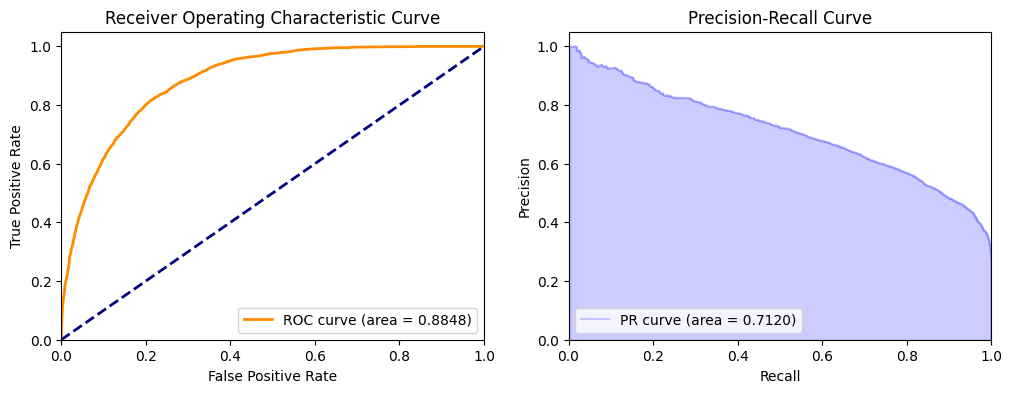

In [22]:
#Add Majed
!pip install handyspark

import handyspark
bcm = handyspark.BinaryClassificationMetrics(predictions, scoreCol='probability', labelCol='label')

import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
bcm.plot_roc_curve(ax=axs[0])
bcm.plot_pr_curve(ax=axs[1])